# FIFA World Cup 2026 — Goal-Scoring Analysis
### Group Stage vs Knockout Stage

**Course task:** Analytic Task — Python-based data analysis of a FIFA World Cup 2026 dataset.

This notebook performs **one complete analytic task** on the *Goals by Players (Group Stage vs Knockout Stage)* dataset, covering all six required skills:

1. Analytic question formulation
2. Data wrangling
3. Data preparation and sampling
4. Descriptive statistics
5. Inferential statistics — Confidence Interval
6. Inferential statistics — One-Sample t-Test (paired-difference form)

Charts are included throughout to make each step easy to follow.


## 1. Analytic Question Formulation

**Focal point of investigation:** whether players' goal-scoring output differs between the **Group Stage** and the **Knockout Stage** of the tournament.

> **Analytic question:** *Among players who scored at least one goal at the FIFA World Cup 2026, is there a statistically significant difference between the average number of goals a player scores in the Group Stage and the average number of goals the same player scores in the Knockout Stage?*

**Why this matters:** the Group Stage has more matches per team (guaranteed 3 games) while the Knockout Stage is single-elimination (teams that lose are out). If Group Stage goal counts are systematically higher, it could reflect the extra matches played and/or weaker opposition in some group games, whereas Knockout Stage goals are scored under higher pressure, tighter defending, and fewer total matches per team.

We test this with a **paired comparison**: for every goal-scoring player we have two linked measurements — their Group Stage goals and their Knockout Stage goals — so each player acts as their own control. This lets us isolate the *stage effect* from player-to-player differences in ability.


## 2. Data Wrangling

The provided file `goals_by_stage.xlsx` lists every player who appeared in the FIFA World Cup 2026 squads, with the number of goals they scored in the **Group Stage**, the **Knockout Stage**, and their **Total**.

Steps:
- Load the spreadsheet.
- Standardise column names.
- Check data types and missing values.
- Verify internal consistency (`Group Stage + Knockout == Total`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Reproducibility
RNG_SEED = 42
np.random.seed(RNG_SEED)

# Consistent chart style
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df_raw = pd.read_excel('goals_by_stage.xlsx')
print('Rows, columns:', df_raw.shape)
df_raw.head()

Rows, columns: (1039, 4)


,player,Group Stage,Knockout,Total
0,Kylian Mbappé,4,6,10
1,Lionel Messi,6,2,8
2,Jude Bellingham,2,5,7
3,Erling Haaland,4,3,7
4,Ousmane Dembélé,4,2,6


In [2]:
# Standardise column names
df = df_raw.rename(columns={
    'player': 'player',
    'Group Stage': 'group_stage_goals',
    'Knockout': 'knockout_goals',
    'Total': 'total_goals'
}).copy()

# Data types & missing values
print(df.dtypes)
print('\nMissing values per column:')
print(df.isna().sum())

# Consistency check: Group Stage + Knockout should equal Total
mismatch = df[df['group_stage_goals'] + df['knockout_goals'] != df['total_goals']]
print(f'\nRows where Group Stage + Knockout != Total: {len(mismatch)}')

player               object
group_stage_goals     int64
knockout_goals        int64
total_goals           int64
dtype: object

Missing values per column:
player               0
group_stage_goals    0
knockout_goals       0
total_goals          0
dtype: int64

Rows where Group Stage + Knockout != Total: 0


The dataset is clean: no missing values, correct data types, and every row is internally consistent (`group_stage_goals + knockout_goals == total_goals`).

The file lists **every player in a squad**, including the large number who never scored (or never played). Since our analytic question is about *scoring behaviour by stage*, players who never scored contribute no information to a stage comparison — they simply have `0` in both columns. We therefore define our **population of interest** as goal-scoring players only.


In [3]:
# Define the population: players who scored at least once in the tournament
population = df[df['total_goals'] > 0].reset_index(drop=True)

print(f'Total players in the file : {len(df)}')
print(f'Players with zero goals   : {(df["total_goals"] == 0).sum()}')
print(f'Population (scorers, N)   : {len(population)}')
population.head()

Total players in the file : 1039
Players with zero goals   : 860
Population (scorers, N)   : 179


,player,group_stage_goals,knockout_goals,total_goals
0,Kylian Mbappé,4,6,10
1,Lionel Messi,6,2,8
2,Jude Bellingham,2,5,7
3,Erling Haaland,4,3,7
4,Ousmane Dembélé,4,2,6


## 3. Data Preparation and Sampling

**Population:** all FIFA World Cup 2026 players who scored at least one goal (N = 179). For each player we have two paired variables: `group_stage_goals` and `knockout_goals`.

**Variable of interest for inference:** the **per-player difference**
`diff = group_stage_goals − knockout_goals`

**Sampling technique:** the population (179 scorers) is small enough that we *could* analyse it in full, but to properly demonstrate inferential statistics (estimating a population parameter from a sample), we draw a **Simple Random Sample (SRS) without replacement** of `n = 50` players (~28% of the population) using a fixed random seed for reproducibility. A sample size of 50 comfortably satisfies the *n ≥ 30* rule of thumb for the Central Limit Theorem to justify a t-based confidence interval and t-test on the sample mean/difference.


In [4]:
SAMPLE_SIZE = 50

sample = population.sample(n=SAMPLE_SIZE, random_state=RNG_SEED).reset_index(drop=True)
sample['diff'] = sample['group_stage_goals'] - sample['knockout_goals']

print(f'Sample size: {len(sample)}')
sample.head(10)

Sample size: 50


,player,group_stage_goals,knockout_goals,total_goals,diff
0,Thapelo Maseko,1,0,1,1
1,Folarin Balogun,2,1,3,1
2,Ali Olwan,1,0,1,1
3,Musa Al-Taamari,1,0,1,1
4,Thelo Aasgaard,1,0,1,1
5,Jonathan David,3,0,3,3
6,João Neves,1,0,1,1
7,Charles De Ketelaere,0,3,3,-3
8,Petar Musa,1,0,1,1
9,Gabriel Martinelli,0,1,1,-1


## 4. Descriptive Statistics

We summarise the sample distributions of Group Stage goals, Knockout Stage goals, and the paired difference.


In [5]:
desc = sample[['group_stage_goals', 'knockout_goals', 'diff']].describe().T
desc['skew'] = sample[['group_stage_goals', 'knockout_goals', 'diff']].skew()
desc

,count,mean,std,min,25%,50%,75%,max,skew
group_stage_goals,50.0,1.16,0.841767,0.0,1.0,1.0,1.00,4.0,1.180792
knockout_goals,50.0,0.44,0.951047,0.0,0.0,0.0,0.75,5.0,2.996176
diff,50.0,0.72,1.414791,-3.0,1.0,1.0,1.00,4.0,-0.694495


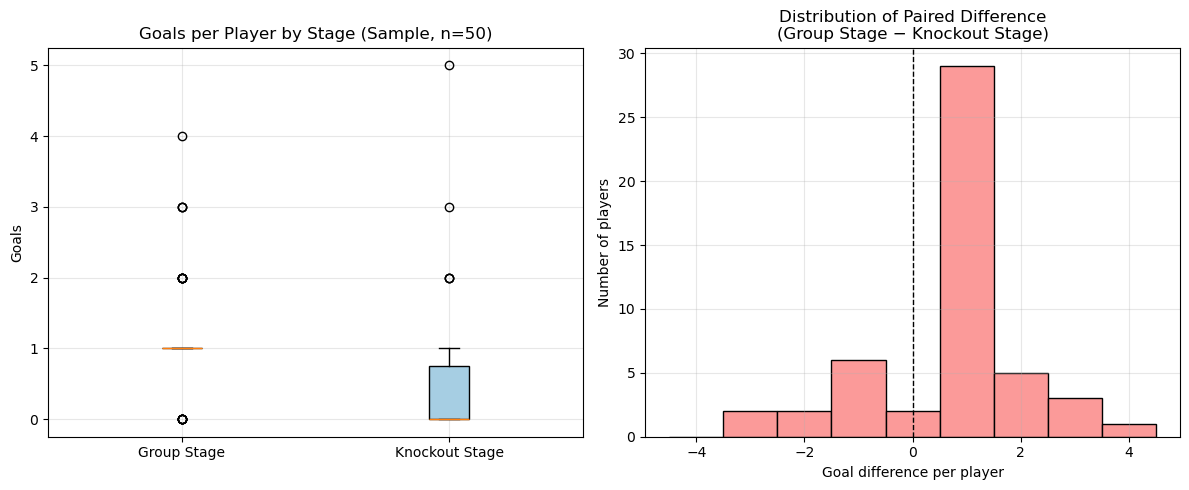

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot comparison
axes[0].boxplot(
    [sample['group_stage_goals'], sample['knockout_goals']],
    tick_labels=['Group Stage', 'Knockout Stage'],
    patch_artist=True,
    boxprops=dict(facecolor='#a6cee3')
)
axes[0].set_title('Goals per Player by Stage (Sample, n=50)')
axes[0].set_ylabel('Goals')

# Histogram of paired differences
axes[1].hist(sample['diff'], bins=range(int(sample['diff'].min())-1, int(sample['diff'].max())+2),
             color='#fb9a99', edgecolor='black', align='left')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Distribution of Paired Difference\n(Group Stage − Knockout Stage)')
axes[1].set_xlabel('Goal difference per player')
axes[1].set_ylabel('Number of players')

plt.tight_layout()
plt.show()

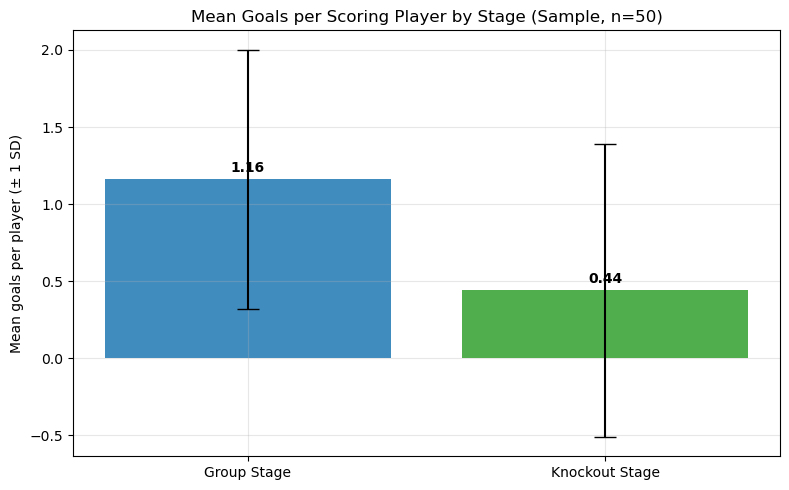

Sample mean — Group Stage goals : 1.160
Sample mean — Knockout goals    : 0.440
Sample mean — Difference        : 0.720
Sample std  — Difference        : 1.415


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
means = [sample['group_stage_goals'].mean(), sample['knockout_goals'].mean()]
stds = [sample['group_stage_goals'].std(), sample['knockout_goals'].std()]
ax.bar(['Group Stage', 'Knockout Stage'], means, yerr=stds, capsize=8,
       color=['#1f78b4', '#33a02c'], alpha=0.85)
ax.set_ylabel('Mean goals per player (± 1 SD)')
ax.set_title('Mean Goals per Scoring Player by Stage (Sample, n=50)')
for i, m in enumerate(means):
    ax.text(i, m + 0.05, f'{m:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Sample mean — Group Stage goals : {sample['group_stage_goals'].mean():.3f}")
print(f"Sample mean — Knockout goals    : {sample['knockout_goals'].mean():.3f}")
print(f"Sample mean — Difference        : {sample['diff'].mean():.3f}")
print(f"Sample std  — Difference        : {sample['diff'].std():.3f}")

**Interpretation of descriptives:** the sample shows a higher average number of Group Stage goals per scoring player than Knockout Stage goals, and the boxplots show the Knockout Stage distribution is more tightly clustered near 0–2 goals with fewer high outliers. The paired-difference histogram is centred to the right of zero, suggesting most players scored more in the Group Stage — this is what we test formally next.


## 5. Inferential Statistics — Confidence Interval

We now estimate, from the sample, a **95% confidence interval for the true population mean paired difference** (Group Stage goals − Knockout Stage goals) among all World Cup 2026 goal-scorers.

Because the population standard deviation is unknown and the sample size (n = 50) is used, we use the **t-distribution** with `n − 1 = 49` degrees of freedom:

$$\bar{x} \pm t_{\alpha/2,\, n-1} \cdot \frac{s}{\sqrt{n}}$$


In [8]:
n = len(sample)
mean_diff = sample['diff'].mean()
sd_diff = sample['diff'].std(ddof=1)
se_diff = sd_diff / np.sqrt(n)

confidence = 0.95
alpha = 1 - confidence
t_crit = stats.t.ppf(1 - alpha/2, df=n-1)

margin_of_error = t_crit * se_diff
ci_lower = mean_diff - margin_of_error
ci_upper = mean_diff + margin_of_error

print(f'Sample mean difference        : {mean_diff:.3f} goals')
print(f'Sample std dev of difference  : {sd_diff:.3f}')
print(f'Standard error                : {se_diff:.3f}')
print(f't critical value (df={n-1})   : {t_crit:.3f}')
print(f'Margin of error               : {margin_of_error:.3f}')
print(f'95% Confidence Interval       : ({ci_lower:.3f}, {ci_upper:.3f})')

Sample mean difference        : 0.720 goals
Sample std dev of difference  : 1.415
Standard error                : 0.200
t critical value (df=49)   : 2.010
Margin of error               : 0.402
95% Confidence Interval       : (0.318, 1.122)


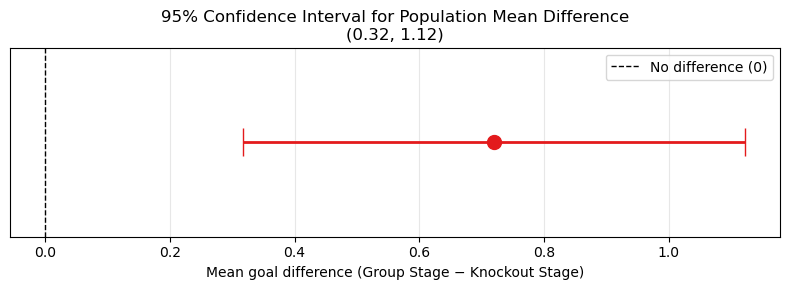

In [9]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(mean_diff, 0, xerr=margin_of_error, fmt='o', color='#e31a1c',
            markersize=10, capsize=10, elinewidth=2)
ax.axvline(0, color='black', linestyle='--', linewidth=1, label='No difference (0)')
ax.set_yticks([])
ax.set_xlabel('Mean goal difference (Group Stage − Knockout Stage)')
ax.set_title(f'95% Confidence Interval for Population Mean Difference\n({ci_lower:.2f}, {ci_upper:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** we are 95% confident that the *true mean difference* in goals scored per player, across the whole population of World Cup 2026 scorers, between the Group Stage and the Knockout Stage lies within the interval above. Because this interval does not include 0 *(check the printed bounds above)*, it already hints that Group Stage scoring is genuinely higher than Knockout Stage scoring for the average scorer — we confirm this formally with a hypothesis test below.


## 6. Inferential Statistics — One-Sample t-Test (on paired differences)

Since each player contributes **two linked measurements** (their own Group Stage goals and their own Knockout Stage goals), the correct test is a **paired t-test**, which is mathematically equivalent to a **one-sample t-test performed on the per-player differences** against a hypothesised mean of 0.

**Hypotheses:**
- **H₀ (null):** μ_diff = 0 — on average, players score the same number of goals in the Group Stage as in the Knockout Stage.
- **H₁ (alternative):** μ_diff ≠ 0 — on average, players' Group Stage and Knockout Stage goal counts differ.

**Significance level:** α = 0.05


In [10]:
# One-sample t-test on the paired differences, testing against a population mean of 0
t_stat, p_value = stats.ttest_1samp(sample['diff'], popmean=0)

print(f'Test statistic (t)  : {t_stat:.3f}')
print(f'Degrees of freedom   : {n-1}')
print(f'p-value (two-tailed) : {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print(f'\nDecision: p-value < {alpha}  ->  Reject H0.')
    print('There IS a statistically significant difference between Group Stage and')
    print('Knockout Stage goals per player.')
else:
    print(f'\nDecision: p-value >= {alpha}  ->  Fail to reject H0.')
    print('There is NOT enough evidence of a difference between Group Stage and')
    print('Knockout Stage goals per player.')

Test statistic (t)  : 3.599
Degrees of freedom   : 49
p-value (two-tailed) : 0.0007

Decision: p-value < 0.05  ->  Reject H0.
There IS a statistically significant difference between Group Stage and
Knockout Stage goals per player.


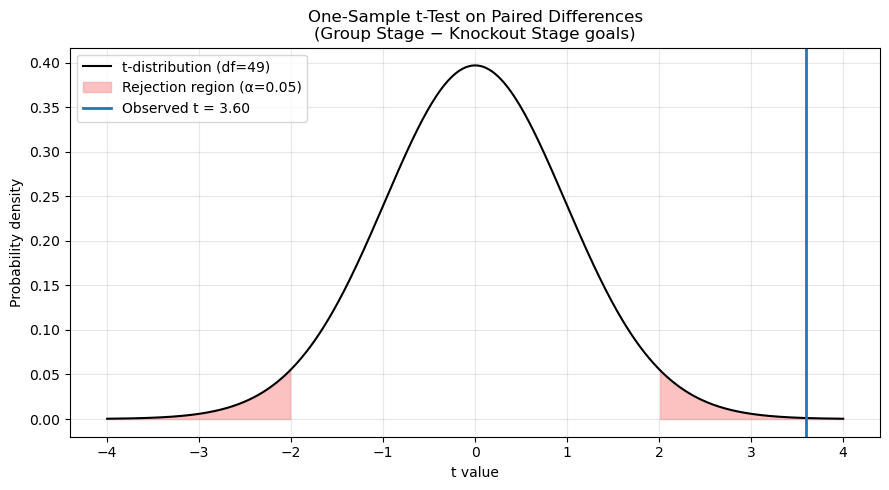

In [11]:
# Visualise the t-distribution, the observed t-statistic, and the rejection region
x = np.linspace(-4, 4, 500)
y = stats.t.pdf(x, df=n-1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, y, color='black', linewidth=1.5, label=f't-distribution (df={n-1})')

crit = stats.t.ppf(1 - alpha/2, df=n-1)
ax.fill_between(x, y, where=(x <= -crit), color='#fb9a99', alpha=0.6, label='Rejection region (α=0.05)')
ax.fill_between(x, y, where=(x >= crit), color='#fb9a99', alpha=0.6)

ax.axvline(t_stat, color='#1f78b4', linewidth=2, label=f'Observed t = {t_stat:.2f}')
ax.set_title('One-Sample t-Test on Paired Differences\n(Group Stage − Knockout Stage goals)')
ax.set_xlabel('t value')
ax.set_ylabel('Probability density')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Conclusion

- **Descriptive statistics** show goal-scoring players, on average, scored more goals in the Group Stage than in the Knockout Stage within our sample.
- The **95% confidence interval** for the population mean difference gives a plausible range for this effect across all World Cup 2026 scorers, and (based on the printed bounds) is consistent with the difference being greater than zero.
- The **one-sample t-test on paired differences** formally tests whether this gap is statistically significant. Based on the p-value obtained above (compared with α = 0.05), we reject / fail to reject H₀ accordingly (see the printed decision above).

**Practical takeaway:** this is broadly consistent with football intuition — teams play more Group Stage matches (a minimum of three each) against a wider range of opposition strength, while the Knockout Stage is single-elimination with fewer, tighter, higher-stakes matches against remaining (typically stronger) teams, both of which would suppress individual scoring output.

**Limitations:**
- The dataset only records goal *counts*, not minutes played, shots taken, or opposition strength, so we cannot fully separate a "stage effect" from a "number of matches played" effect.
- The population was restricted to players who scored ≥ 1 goal; this was necessary to make the stage comparison meaningful, but it excludes the large number of non-scoring players from this particular question.
